# Waifu Diffusion

Waifu Diffusion with EADS scheduler.

### Waifu Diffusion Huggingface
https://huggingface.co/hakurei/waifu-diffusion

### Prompts guide
https://www.reddit.com/r/WaifuDiffusion/comments/xudcdp/prompts_guide_by_cdcruz/

### Image upscaling with Real-ESRGAN
https://huggingface.co/spaces/akhaliq/Real-ESRGAN

In [1]:
try:
    import diffusers
except:
    !pip install -q transformers==4.25.1
    !pip install -q accelerate==0.15.0
    !pip install -q diffusers==0.11.1
    import diffusers

import os
import time

import torch
import matplotlib.pyplot as plt
import numpy as np

if torch.backends.mps.is_available():
    device_name = torch.device("mps")
if torch.cuda.is_available():
    device_name = torch.device("cuda")
else:
    device_name = torch.device("cpu")

print("Using {}.".format(device_name))

Using cuda.


In [2]:
# Load (text to image) diffuser pipeline.
def load_pipeline(model_dir, scheduler = None, device_name = torch.device("cpu")):
    pipe = diffusers.StableDiffusionPipeline.from_pretrained(model_dir, torch_dtype = torch.float32)

    # Change scheduler if not set to None. By default PNDMScheduler is used.
    if scheduler in ["EulerAncestralDiscreteScheduler", "EADS"]:
        pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["EulerDiscreteScheduler", "EDS"]:
        pipe.scheduler = diffusers.EulerDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler in ["DPMSolverMultistepScheduler", "DPMSMS"]:
        pipe.scheduler = diffusers.DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

# Load image to image diffuser pipeline.
def load_img2img_pipeline(model_dir, device_name):
    pipe = diffusers.StableDiffusionImg2ImgPipeline.from_pretrained(model_dir, torch_dtype = torch.float16)
    pipe.scheduler = diffusers.EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    pipe.safety_checker = lambda images, **kwargs: [images, [False] * len(images)]
    pipe = pipe.to(device_name)
    return pipe

In [3]:
# Run diffuser pipeline.
def run_pipe(pipe, prompt, negative_prompt = None, steps = 60, 
             width = 512, height = 704, scale = 8.0, seed = 123, n_images = 1):
    if width % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        width = int(width / 8) * 8
    if height % 8 != 0:
        print("Image width must be multiples of 8... adjusting!")
        height = int(height / 8) * 8

    gen = torch.Generator(device = device_name).manual_seed(seed)
    image_list = []
    with torch.autocast("cuda"): 
        for i in range(n_images): 
            image = pipe(prompt, height = height, width = width, 
                         num_inference_steps = steps, guidance_scale = scale,
                         negative_prompt = negative_prompt, generator = gen)
            image_list = image_list + image.images

    return image_list

In [4]:
# Plot pipeline outputs.
def plot_images(images, labels = None):
    N = len(images)
    n_cols = 5
    n_rows = int(np.ceil(N / n_cols))

    plt.figure(figsize = (20, 5 * n_rows))
    for i in range(len(images)):
        plt.subplot(n_rows, n_cols, i + 1)
        if labels is not None:
            plt.title(labels[i])
        plt.imshow(np.array(images[i]))
        plt.axis(False)
    plt.show()

In [5]:
model_dir = "hakurei/waifu-diffusion"

# Text to image pipe line. EADS scheduler.
pipe_eads = load_pipeline(model_dir, "EADS", device_name)

# Image to image pipeline.
#img2img_pipe = load_img2img_pipeline(model_dir, device_name)

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

## WD Trial 0 - EADS Scheduler

Apaprently Waifu Diffusion models work best with the Euler Ancestral Discrete Scheduler (EADS).

In [6]:
# For use with EADS scheduler.
prompt_0 = """((masterpiece)),(best quality),(8k),(beautiful detailed face),photorealistic,(perfect anatomy),(1girl),solo,long hair,
(white bikini),(large breasts),spreading legs,(pleasured expression),slim,thin waist,(mature woman),perfect face,(cleavage)"""

negative_prompt = """(worst quality),(low quality),medium quality,deleted,lowres,cartoon,3d,comic,(bad anatomy),bad hands,text,error,
(deformed),(blurry),missing fingers,extra digit,fewer digits,(disfigured),(poorly drawn face),mutation,mutated,extra limb,ugly,
poorly drawn hands,two heads,child,kid,gross,mutilated,disgusting,horrible,scary,evil,old,conjoined"""

In [7]:
images_0 = run_pipe(pipe_eads, prompt_0, negative_prompt, steps = 60, width = 512, height = 704, scale = 8.0, seed = 123, n_images = 1)

  0%|          | 0/60 [00:00<?, ?it/s]

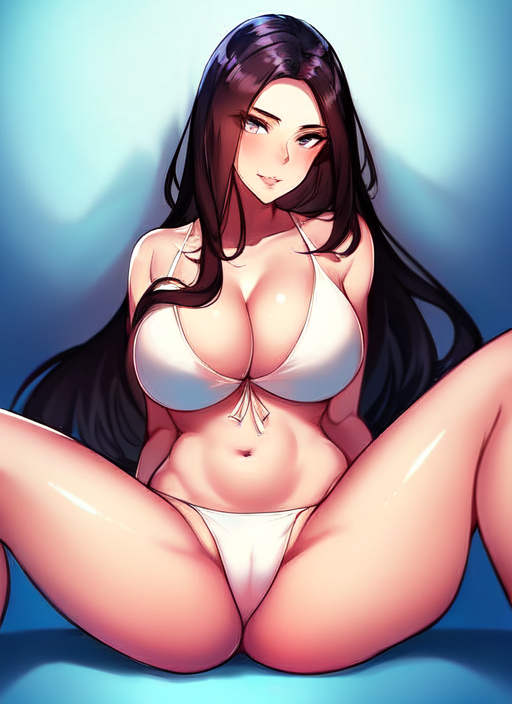

In [8]:
[display(i) for i in images_0];

In [16]:
images_1 = run_pipe(pipe_eads, prompt_0, negative_prompt, steps = 64, width = 512, height = 704, scale = 8.0, seed = 1029384756, n_images = 1)

  0%|          | 0/64 [00:00<?, ?it/s]

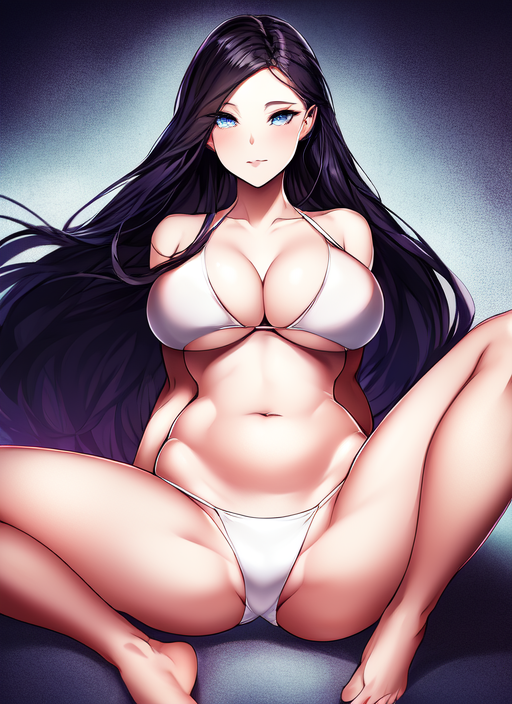

In [17]:
[display(i) for i in images_1];

### WD 0 - Same Seed Across Various Steps

In [9]:
#steps = list(range(51, 70 + 1, 1))
#images_1_steps = []
#for s in steps:
#    images_1_steps += run_pipe(pipe_eads, prompt_0, negative_prompt, steps = s, width = 512, height = 704, scale = 8.0, seed = 1029384756, n_images = 1)

In [10]:
#plot_images(images_1_steps, steps)

### WD Trial 0 - Same Seed Different Image Dimensions.

In [14]:
images_2 = run_pipe(pipe_eads, prompt_0, negative_prompt, steps = 63, width = 600, height = 800, scale = 8.0, seed = 1029384756, n_images = 1)

  0%|          | 0/63 [00:00<?, ?it/s]

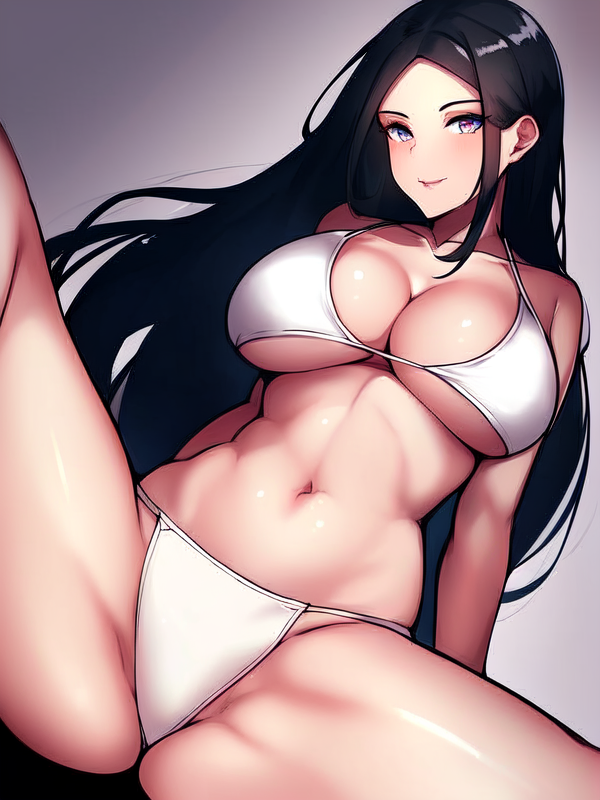

In [15]:
[display(i) for i in images_2];

## WD Trial 0 - Different Prompt

In [51]:
prompt_3 = """((masterpiece)),(best quality),(8k),(beautiful detailed face),photorealistic,(perfect anatomy),(1girl),solo,long hair,
(white bikini),(large breasts),covered nipples,seaside,(sexy expression),slim,thin waist,(mature woman),perfect face,cleavage"""

In [56]:
images_3 = run_pipe(pipe_eads, prompt_3, negative_prompt, steps = 69, width = 600, height = 800, scale = 8, seed = 58, n_images = 1)

  0%|          | 0/69 [00:00<?, ?it/s]

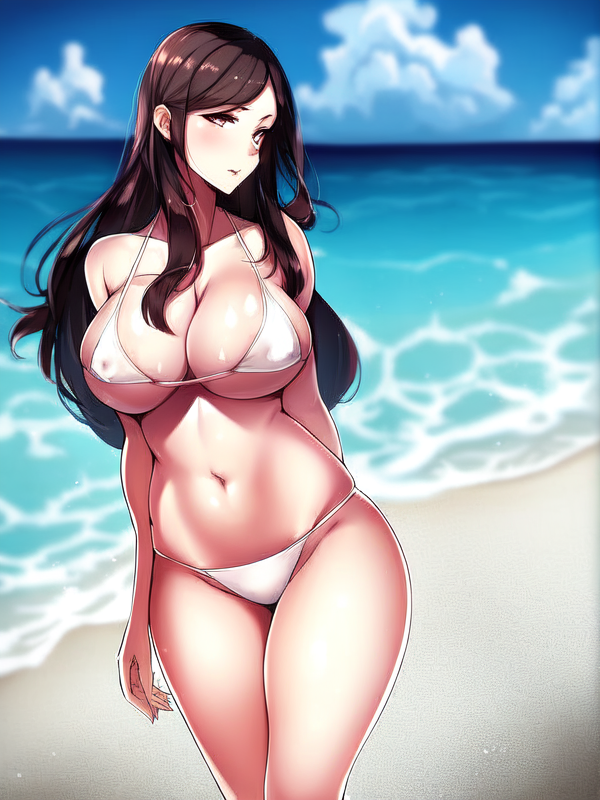

In [57]:
[display(i) for i in images_3];